# ***Modeling an autoregressive process***

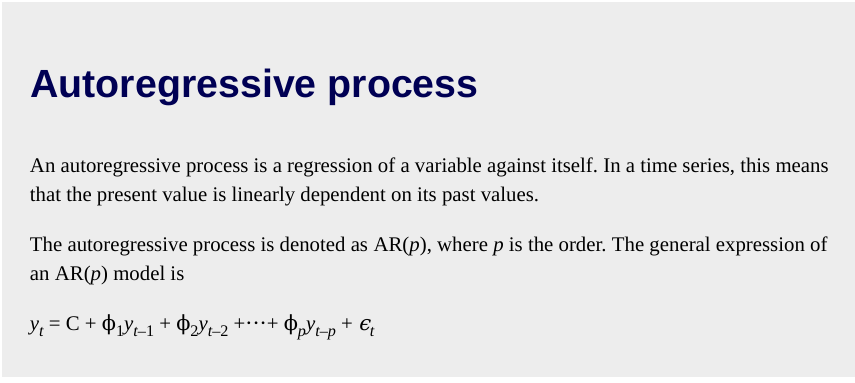

#### ***In AR(1) model if the cofficient value is 1 then the equation represent random walk's equantion , so we can say that the random walk is the special case of AR model,*** ****if c!=0 then it is random walk with drift****

## **Finding the order of a stationary autoregressive process**

### Just like with the moving average process, there is a way to determine the order p of a stationary autoregressive process. We can extend the steps needed to identify the order of a moving average, as shown in figure.

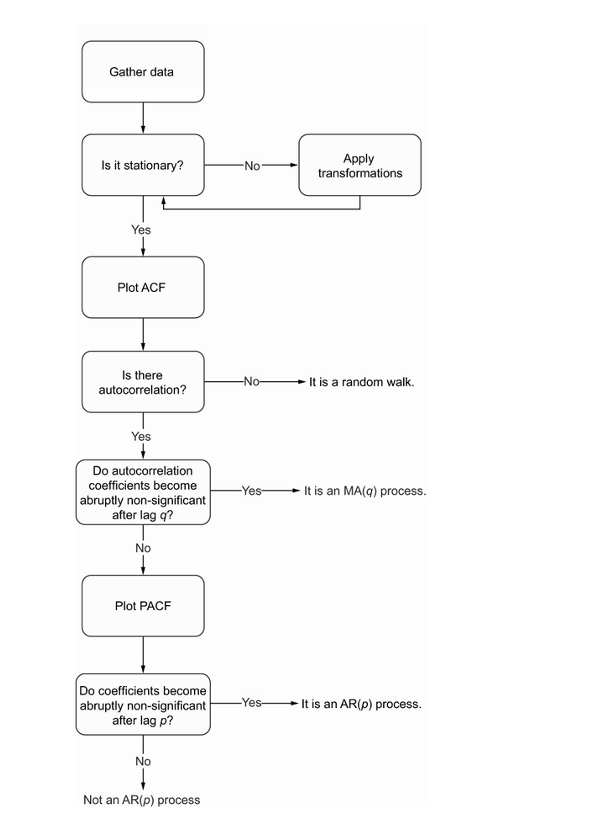

In [2]:
# importing libraries and prerequisite
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.tsa.stattools as sts
import statsmodels.graphics.tsaplots as sgt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

### ***NOW WE ARE TO GOING TO APPLY THESE STEPS***

### **1-) Gather data**

In [3]:
df=pd.read_csv('foot_traffic.csv')
df.head()

,foot_traffic
0,500.496714
1,500.522366
2,501.426876
3,503.295990
4,504.132695


#### **plotting the data**

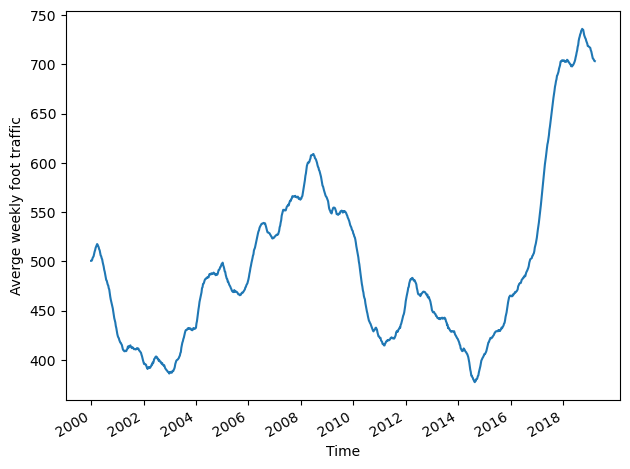

In [8]:
fig ,ax=plt.subplots()
ax.plot(df['foot_traffic'])
ax.set_xlabel('Time')
ax.set_ylabel('Averge weekly foot traffic')
plt.xticks(np.arange(0,1000,104),np.arange(2000,2020,2))
fig.autofmt_xdate() #This automatically rotates and formats the x-axis date labels so they don't overlap each other.
plt.tight_layout() #This automatically adjusts spacing between subplots and figure edges so nothing gets cut off.

#### verage weekly foot traffic in a retail store. The dataset contains 1,000 data points, starting in the first week of 2000.

#### **The next step is to check for stationarity. As mentioned before, the presence of a trend means that our series is likely non-stationary. Let’s verify that using the ADF test.**

### **2-) Stationarity**

In [9]:
sts.adfuller(df['foot_traffic'])

(np.float64(-1.175888599924076),
 np.float64(0.6838808917896184),
 3,
 996,
 {'1%': np.float64(-3.4369325637409154),
  '5%': np.float64(-2.8644462162311934),
  '10%': np.float64(-2.568317409920808)},
 np.float64(2740.300875453594))

### As we can see that the p-value=0.68 which is greater than 0.05 and test-statistic > table value so the data is not stationary.

### **3-) Applying Transformation**

In [11]:
foot_traffic_diff=np.diff(df['foot_traffic'],n=1)

,foot_traffic
0,500.496714
1,500.522366
2,501.426876
3,503.295990
4,504.132695


#### ***Plotting the graph of transformation***

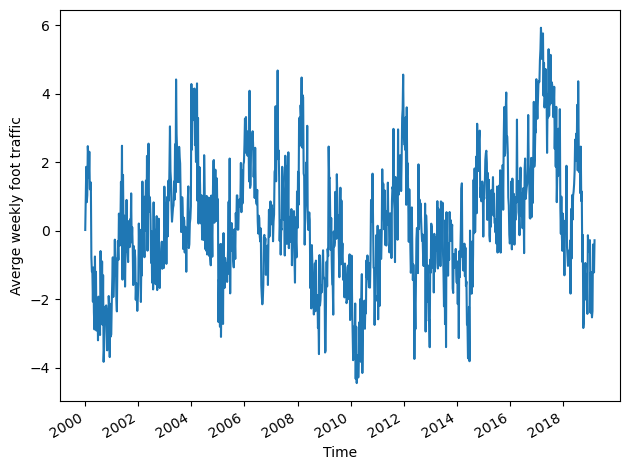

In [13]:
fig ,ax=plt.subplots()
ax.plot(foot_traffic_diff)
ax.set_xlabel('Time')
ax.set_ylabel('Averge weekly foot traffic')
plt.xticks(np.arange(0,1000,104),np.arange(2000,2020,2))
fig.autofmt_xdate() #This automatically rotates and formats the x-axis date labels so they don't overlap each other.
plt.tight_layout() #This automatically adjusts spacing between subplots and figure edges so nothing gets cut off.

 Differenced average weekly foot traffic at a retail store.
Notice that the trend effect has been removed, since the series starts and
ends at roughly the same value.

### **Stationarity of transformation**

In [14]:
sts.adfuller(foot_traffic_diff)

(np.float64(-5.268231347422041),
 np.float64(6.369317654781405e-06),
 2,
 996,
 {'1%': np.float64(-3.4369325637409154),
  '5%': np.float64(-2.8644462162311934),
  '10%': np.float64(-2.568317409920808)},
 np.float64(2735.535696297212))

### As we can see that that the p-value < 0.05 and test-statistic < table value so our  data is stationary

### **4-) plotting ACF graph**

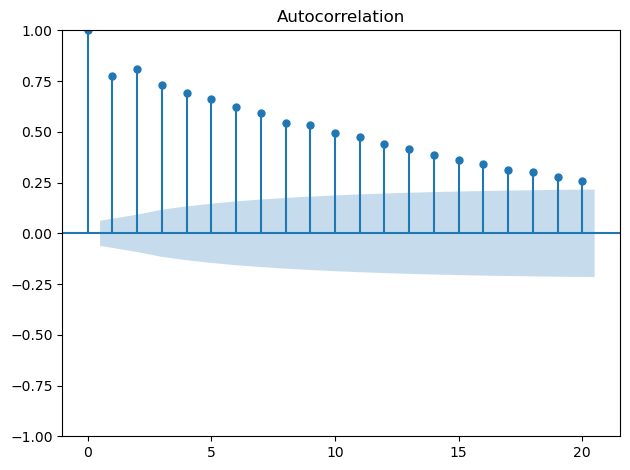

In [18]:
sgt.plot_acf(foot_traffic_diff,lags=20)
plt.tight_layout()

### *ACF plot of the differenced average weekly foot traffic at a retail store. Notice how the plot is slowly decaying. This is a behavior that we have not observed before, and it is indicative of an autoregressive process.*

you’ll notice that we have significant autocorrelation
coefficients beyond lag 0. Therefore, we know that our process is not a
random walk. Furthermore, you’ll notice that the coefficients are decaying
exponentially as the lag increases. Therefore, there is no lag at which the
coefficients abruptly become non-significant. This means that we do not
have a moving average process and that we are likely studying an
autoregressive process

Remember that the autocorrelation measures the linear relationship between
lagged values of a time series. Consequently, the autocorrelation function
measures how the correlation changes between two values as the lag is
increased.

### **PACF**

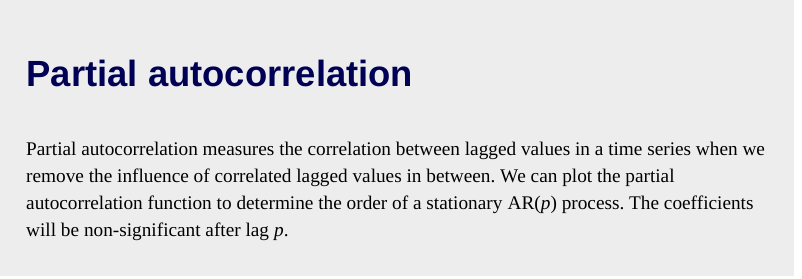

### **5-) plotting PACF graph**

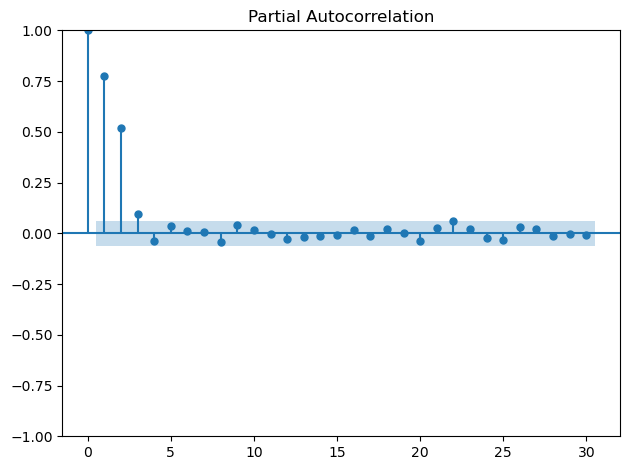

In [19]:
sgt.plot_pacf(foot_traffic_diff)
plt.tight_layout()

### *The PACF of our differenced average weekly foot traffic in a retail store. You can see that the coefficients are non-significant after lag3. Therefore, we can say that our stationary process is a third-order autoregressive process, or an AR(3) process.*

### **5-) Forecasting an autoregressive process**

Once the order is determined, we can fit an autoregressive model to forecast
our time series. In this case, the model is also termed AR(p), where p is still
the order of the process.

We will forecast next week’s average foot traffic in a retail store using the
same dataset we have been working with. In order to evaluate our forecasts,
we will hold out the last 52 weeks of data for our test set, while the rest will
be used for training. That way, we can evaluate the performance of our
forecast over a period of 1 year.

In [23]:
df_diff=pd.DataFrame({'foot_traffic_diff': foot_traffic_diff})
df_diff.head()

,foot_traffic_diff
0,0.025651
1,0.904511
2,1.869114
3,0.836705
4,1.039848


#### *SPLITTING DATA INTO 2 PARTS TRAIN AND TEST*

In [24]:
train=df_diff[:-52]
test=df_diff[-52:]
print(len(train))
print(len(test))

947
52


### *visualize the testing period for our scenario, in both the original series and the differenced series*

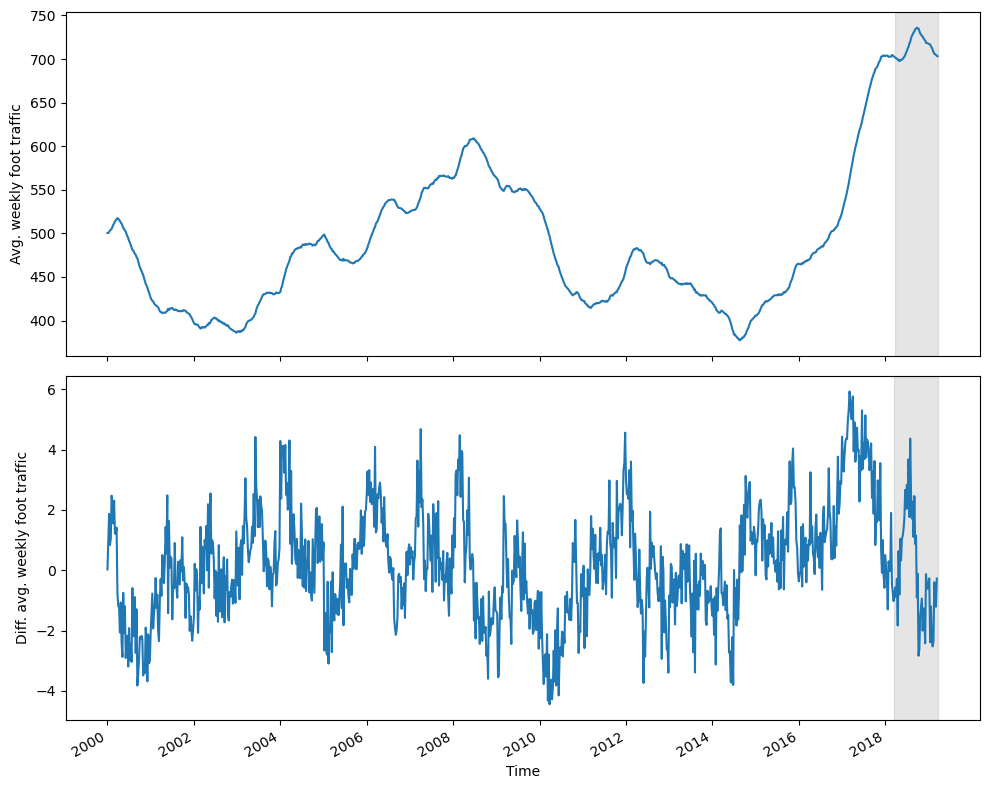

In [25]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(10, 8))

ax1.plot(df['foot_traffic'])
ax1.set_xlabel('Time')
ax1.set_ylabel('Avg. weekly foot traffic')
ax1.axvspan(948, 1000, color='#808080', alpha=0.2)

ax2.plot(df_diff['foot_traffic_diff'])
ax2.set_xlabel('Time')
ax2.set_ylabel('Diff. avg. weekly foot traffic')
ax2.axvspan(947, 999, color='#808080', alpha=0.2)

plt.xticks(np.arange(0, 1000, 104), np.arange(2000, 2020, 2))

fig.autofmt_xdate()
plt.tight_layout()

## ***Forcasting***

We will forecast using three different methods. The historical mean method
and the last known value method will act as baselines, and we will use an
AR(3) model

In [27]:
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:
    
    total_len = train_len + horizon
    end_idx = train_len
    
    if method == 'mean':
        pred_mean = []
        
        for i in range(train_len, total_len, window):
            mean = np.mean(df[:i].values)
            pred_mean.extend(mean for _ in range(window))
            
        return pred_mean

    elif method == 'last':
        pred_last_value = []
        
        for i in range(train_len, total_len, window):
            last_value = df[:i].iloc[-1].values[0]
            pred_last_value.extend(last_value for _ in range(window))
            
        return pred_last_value
    
    elif method == 'AR':
        pred_AR = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order=(3,0,0))
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_AR.extend(oos_pred)
            
        return pred_AR

In [28]:
TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 1

pred_mean = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'mean')
pred_last_value = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'last')
pred_AR = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'AR')

test['pred_mean'] = pred_mean
test['pred_last_value'] = pred_last_value
test['pred_AR'] = pred_AR

test.head()

,foot_traffic_diff,pred_mean,pred_last_value,pred_AR
947,-0.776601,0.213270,-1.021893,-0.719714
948,-0.574631,0.212226,-0.776601,-0.814547
949,-0.890697,0.211397,-0.574631,-0.664738
950,-0.283552,0.210237,-0.890697,-0.641469
951,-1.830685,0.209717,-0.283552,-0.579279


## **visualize our predictions against the observed values in the test set.**

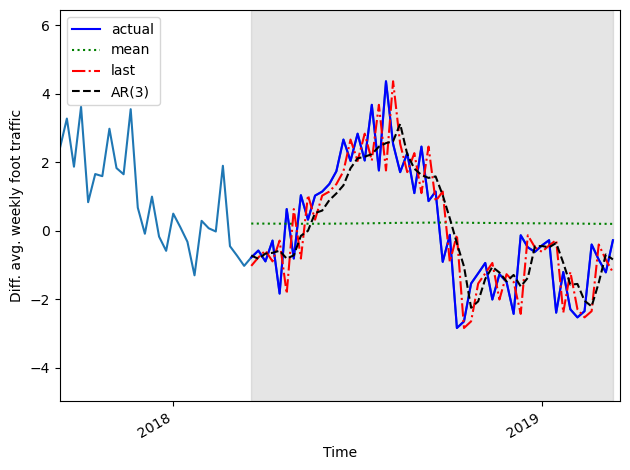

In [29]:
fig, ax = plt.subplots()

ax.plot(df_diff['foot_traffic_diff'])
ax.plot(test['foot_traffic_diff'], 'b-', label='actual')
ax.plot(test['pred_mean'], 'g:', label='mean')
ax.plot(test['pred_last_value'], 'r-.', label='last')
ax.plot(test['pred_AR'], 'k--', label='AR(3)')

ax.legend(loc=2)

ax.set_xlabel('Time')
ax.set_ylabel('Diff. avg. weekly foot traffic')

ax.axvspan(947, 998, color='#808080', alpha=0.2)

ax.set_xlim(920, 999)

plt.xticks([936, 988],[2018, 2019])

fig.autofmt_xdate()
plt.tight_layout()

###  you’ll see that, once again, using the historical mean produces a straight line, which is shown in the plot as a dotted line. As for the predictions from the AR(3) model and the last known value method, the curves are almost confounding with that of the test set, so we will have to measure the MSE to assess which method is the most performant. Again, we will use the mean_squared_error function from the sklearn library

In [31]:

from sklearn.metrics import mean_squared_error

mse_mean = mean_squared_error(test['foot_traffic_diff'], test['pred_mean'])
mse_last = mean_squared_error(test['foot_traffic_diff'], test['pred_last_value'])
mse_AR = mean_squared_error(test['foot_traffic_diff'], test['pred_AR'])

print(mse_mean, mse_last, mse_AR)

3.1079979374701447 1.448730118495964 0.9242479162986939


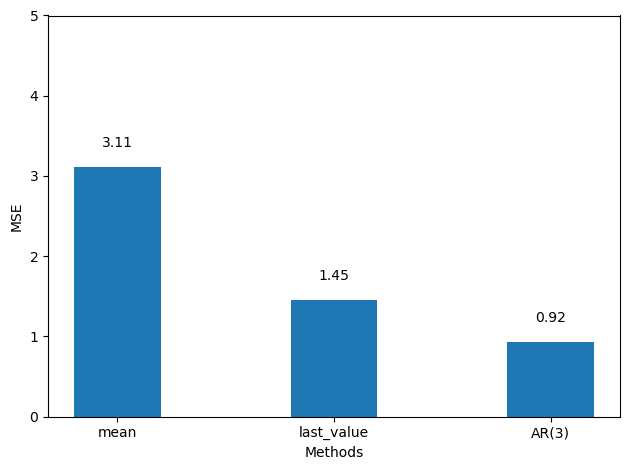

In [32]:
fig, ax = plt.subplots()

x = ['mean', 'last_value', 'AR(3)']
y = [mse_mean, mse_last, mse_AR]

ax.bar(x, y, width=0.4)
ax.set_xlabel('Methods')
ax.set_ylabel('MSE')
ax.set_ylim(0, 5)

for index, value in enumerate(y):
    plt.text(x=index, y=value+0.25, s=str(round(value, 2)), ha='center')

plt.tight_layout()

This prints out an MSE of 3.11 for the historical mean method, 1.45 for the
last known value method, and 0.92 for the AR(3) model. Since the MSE for
the AR(3) model is the lowest of the three, we conclude that the AR(3)
model is the best-performing method for forecasting next week’s average
foot traffic. This is expected, since we established that our stationary process
was a third-order autoregressive process. It makes sense that modeling using
an AR(3) model will yield the best predictions

### *Since our forecasts are differenced values, we need to reverse the transformation in order to bring our forecasts back to the original scale of the data; otherwise, our predictions will not make sense in a business context. To do this, we can take the cumulative sum of our predictions and add it to the last value of our training set in the original series. This point occurs at index 948, since we are forecasting the last 52 weeks in a dataset containing 1,000 points.*

In [34]:

df['pred_foot_traffic'] = pd.Series()
df['pred_foot_traffic'][948:] = df['foot_traffic'].iloc[948] + test['pred_AR'].cumsum()

### **Now we can plot our undifferenced predictions against the observed values in the test set of the original series in its original scale.**

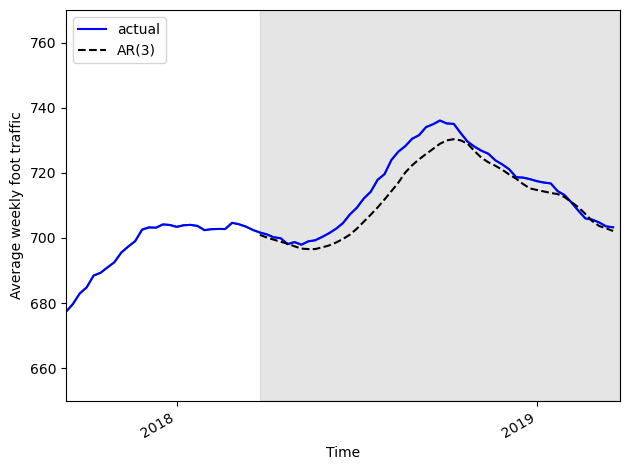

In [35]:
fig, ax = plt.subplots()

ax.plot(df['foot_traffic'])
ax.plot(df['foot_traffic'], 'b-', label='actual')
ax.plot(df['pred_foot_traffic'], 'k--', label='AR(3)')

ax.legend(loc=2)

ax.set_xlabel('Time')
ax.set_ylabel('Average weekly foot traffic')

ax.axvspan(948, 1000, color='#808080', alpha=0.2)

ax.set_xlim(920, 1000)
ax.set_ylim(650, 770)

plt.xticks([936, 988],[2018, 2019])

fig.autofmt_xdate()
plt.tight_layout()

## ***Undifferenced forecasts from the AR(3) model***

### ***Now we can measure the mean absolute error (MAE) on the original dataset to get its meaning in a business context.***

In [36]:
from sklearn.metrics import mean_absolute_error

mae_AR_undiff = mean_absolute_error(df['foot_traffic'][948:], df['pred_foot_traffic'][948:])

print(mae_AR_undiff)

3.4780335576573864


This prints out a mean absolute error of 3.45. This means that our
predictions are off by 3.45 people on average, either above or below the
actual value for the week’s foot traffic. Note that we report the MAE because
it has a simple business meaning that is easy to understand and interpret.